# From Spot Shift to Two-Layer Wavefront Tomography

This notebook is a cleaned, teaching-oriented version of the original **v1.5** simulation.

## Problem

Can measurements from multiple source directions be used to separate two hidden aberrating layers?

## Pipeline

**Point sources → ray-layer intersections → summed wavefront tilt → lenslet spot displacement → cross-correlation → linear tomography → reconstructed OPD**

## What this notebook demonstrates

1. Why multiple source directions provide **tomographic diversity**.
2. How lenslet spot displacement encodes local **wavefront tilt**.
3. How the two-layer inverse problem can be written as $\mathbf{b}=\mathbf{A}\mathbf{x}$.
4. Why **regularisation** is needed to stabilise layer separation.
5. How estimated layer tilts can be integrated back into **optical path difference (OPD)**.

## Scope and units

This is intentionally a **1D toy tomography model**. All spatial coordinates and OPD values use **normalised simulation units** rather than a specific instrument's SI dimensions.

Under the paraxial approximation, the local OPD slope is treated as a small angular perturbation:

$$\theta_{\mathrm{turb}} \approx \frac{dW}{dy}.$$

The aim is to make the inverse-problem structure easy to understand before extending the model to full 2D wavefront sensing, physical diffraction, and more realistic turbulence.


## 1. System Geometry and Sources

All main simulation parameters are collected here so that the model can be modified from one place.

Multiple point sources are essential: different source directions intersect the two hidden layers at different positions. Those different footprints provide the diversity needed to separate the layers.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# ============================================================
# Simulation configuration
# ============================================================

# Geometry (normalised simulation units)
z_source = 1.0
z_lenslet = 0.0
z_sensor = -0.25
f_ml = abs(z_sensor - z_lenslet)

# Hidden layer locations
z_layers = np.array([0.35, 0.70])

# Lenslet array
n_lenslets = 17
lenslet_pitch = 0.025
lenslet_radius = 0.008

lenslet_centers_y = (
    np.arange(n_lenslets) - (n_lenslets - 1) / 2
) * lenslet_pitch
aperture_radius = np.max(np.abs(lenslet_centers_y)) + lenslet_pitch / 2

# Point sources: [y_source, relative flux]
point_sources = np.array([
    [-0.18, 0.45],
    [-0.135, 0.60],
    [-0.09, 0.78],
    [-0.045, 0.92],
    [0.00, 1.00],
    [0.045, 0.92],
    [0.09, 0.78],
    [0.135, 0.60],
    [0.18, 0.45],
])
n_sources = len(point_sources)

# 1D Kolmogorov-like layer parameters
kolmogorov_n_grid = 4096
layer_specs = [
    {"name": "Layer 1", "z": z_layers[0], "seed": 4,  "rms_opd": 0.0025},
    {"name": "Layer 2", "z": z_layers[1], "seed": 12, "rms_opd": 0.0030},
]

# Measurement settings
measurement_noise_std = 0.0
image_noise_std = 0.0

print("Simulation summary")
print("------------------")
print(f"Sources:              {n_sources}")
print(f"Lenslets:             {n_lenslets}")
print(f"Source plane z:       {z_source:.2f}")
print(f"Layer z positions:    {z_layers.tolist()}")
print(f"Lenslet plane z:      {z_lenslet:.2f}")
print(f"Sensor plane z:       {z_sensor:.2f}")
print(f"Normalised aperture:  ±{aperture_radius:.3f}")


Simulation summary
------------------
Sources:              9
Lenslets:             17
Source plane z:       1.00
Layer z positions:    [0.35, 0.7]
Lenslet plane z:      0.00
Sensor plane z:       -0.25
Normalised aperture:  ±0.213


## 2. Hidden Turbulent Layers

The two aberrating layers are **ground truth**. They generate the synthetic measurements and are used only later for validation.

**Hidden truth → Forward simulation → Sensor measurement → Reconstruction → Validation**

### Simplified turbulence model

This notebook uses a **1D Kolmogorov-like** OPD screen. Its high-frequency power spectral density is approximated as

$$PSD_{1D}(f)\propto f^{-8/3}.$$

This is deliberately simpler than a full 2D atmospheric phase-screen model. Its purpose is only to provide spatially correlated test aberrations for the tomography example.


In [2]:
def y_at_layer(y_source, y_lens, z_layer):
    """Unperturbed ray position at a hidden layer."""
    fraction = (z_layer - z_lenslet) / (z_source - z_lenslet)
    return y_lens + (y_source - y_lens) * fraction


# The simulated screens must cover all source-lenslet intersections.
all_layer_hits = []
for z_layer in z_layers:
    for y_source, _ in point_sources:
        for y_lens in lenslet_centers_y:
            all_layer_hits.append(y_at_layer(y_source, y_lens, z_layer))

screen_extent = max(aperture_radius, np.max(np.abs(all_layer_hits))) + lenslet_pitch
y_screen = np.linspace(-screen_extent, screen_extent, kolmogorov_n_grid)


def make_kolmogorov_like_screen(y_grid, seed, rms_opd, inner_scale, outer_scale):
    """Create a smooth 1D Kolmogorov-like OPD screen and its local slope."""
    n_grid = len(y_grid)
    dy = y_grid[1] - y_grid[0]
    freq = np.fft.rfftfreq(n_grid, d=dy)

    rng = np.random.default_rng(seed)
    f0 = 1.0 / outer_scale
    fm = 1.0 / inner_scale

    # High-frequency limit: PSD ~ f^(-8/3)
    psd_1d = (freq**2 + f0**2)**(-4.0 / 3.0) * np.exp(-(freq / fm)**2)
    psd_1d[0] = 0.0

    random_complex = (
        rng.normal(size=freq.size)
        + 1j * rng.normal(size=freq.size)
    )

    spectrum = random_complex * np.sqrt(psd_1d)
    spectrum[0] = 0.0

    W = np.fft.irfft(spectrum, n=n_grid)
    W -= np.mean(W)
    W = W / np.std(W) * rms_opd

    # Remove arbitrary global tip/tilt from each hidden screen.
    dWdy = np.gradient(W, y_grid)
    W -= np.mean(dWdy) * y_grid
    W -= np.mean(W)
    W = W / np.std(W) * rms_opd

    dWdy = np.gradient(W, y_grid)
    dWdy -= np.mean(dWdy)

    return W, dWdy


turbulent_layers = []
for spec in layer_specs:
    layer = dict(spec)
    W, dWdy = make_kolmogorov_like_screen(
        y_screen,
        seed=layer["seed"],
        rms_opd=layer["rms_opd"],
        inner_scale=3.0 * lenslet_pitch,
        outer_scale=2.0 * screen_extent,
    )
    layer["W"] = W
    layer["dWdy"] = dWdy
    turbulent_layers.append(layer)


def layer_opd(layer, y):
    return np.interp(y, y_screen, layer["W"])


def layer_tilt(layer, y):
    return np.interp(y, y_screen, layer["dWdy"])


def total_turbulent_tilt(y_source, y_lens):
    """Return the summed angular perturbation and per-layer contributions."""
    per_layer_tilts = []
    per_layer_hits = []

    for layer in turbulent_layers:
        y_hit = y_at_layer(y_source, y_lens, layer["z"])
        tilt = layer_tilt(layer, y_hit)
        per_layer_hits.append(y_hit)
        per_layer_tilts.append(tilt)

    return np.sum(per_layer_tilts), per_layer_tilts, per_layer_hits

print(f"Hidden-screen y range: {y_screen[0]:.3f} to {y_screen[-1]:.3f}")


Hidden-screen y range: -0.238 to 0.238


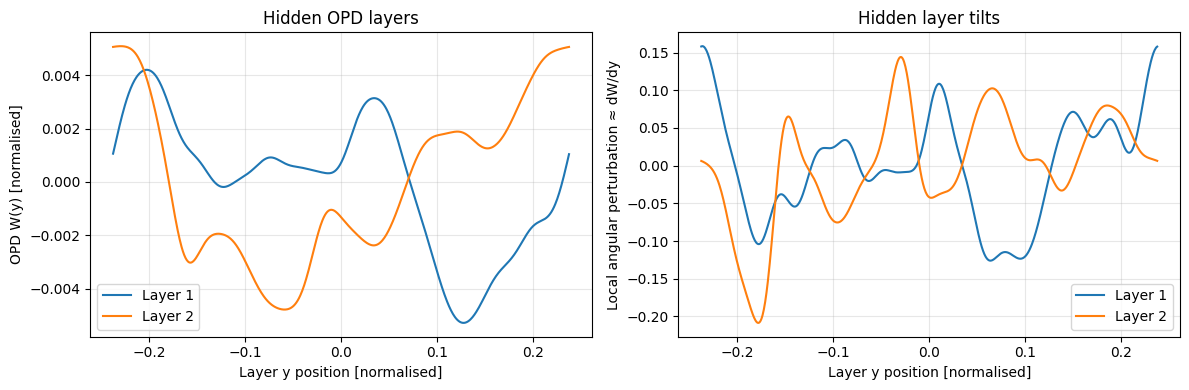

In [3]:
# Ground-truth visualisation only.
y_plot = np.linspace(-screen_extent, screen_extent, 700)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for layer in turbulent_layers:
    axes[0].plot(y_plot, layer_opd(layer, y_plot), label=layer["name"])
    axes[1].plot(y_plot, layer_tilt(layer, y_plot), label=layer["name"])

axes[0].set_xlabel("Layer y position [normalised]")
axes[0].set_ylabel("OPD W(y) [normalised]")
axes[0].set_title("Hidden OPD layers")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Layer y position [normalised]")
axes[1].set_ylabel("Local angular perturbation ≈ dW/dy")
axes[1].set_title("Hidden layer tilts")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. Forward Ray-Tracing Model

For each source-lenslet pair, the unperturbed ray intersects each hidden layer at a different $y$ position.

The total propagation angle is approximated by

$$\theta_{\mathrm{total}}=\theta_{\mathrm{source}}+T_1(y_1)+T_2(y_2).$$

The microlens converts this angle into a sensor spot position:

$$y_{\mathrm{spot}}=y_{\mathrm{lens}}-f_{\mathrm{ML}}\tan(\theta_{\mathrm{total}}).$$

The key tomography idea is that changing the source direction changes $y_1$ and $y_2$. Therefore, different measurements probe different combinations of the two hidden layers.


In [4]:
def trace_one_ray(y_source, y_lens, use_turbulence=True):
    """Trace one source-lenslet ray to the sensor."""
    theta_source = np.arctan2(
        y_lens - y_source,
        z_source - z_lenslet
    )

    if use_turbulence:
        theta_turbulence, per_layer_tilts, per_layer_hits = total_turbulent_tilt(
            y_source, y_lens
        )
    else:
        theta_turbulence = 0.0
        per_layer_tilts = [0.0 for _ in turbulent_layers]
        per_layer_hits = [
            y_at_layer(y_source, y_lens, layer["z"])
            for layer in turbulent_layers
        ]

    theta_total = theta_source + theta_turbulence
    y_spot = y_lens - f_ml * np.tan(theta_total)

    return {
        "y_source": y_source,
        "y_lens": y_lens,
        "theta_source": theta_source,
        "theta_turbulence": theta_turbulence,
        "theta_total": theta_total,
        "y_spot": y_spot,
        "per_layer_tilts": per_layer_tilts,
        "per_layer_hits": per_layer_hits,
    }


rays_no_turbulence = []
rays_with_turbulence = []

for source_id, (y_source, flux) in enumerate(point_sources):
    for lenslet_id, y_lens in enumerate(lenslet_centers_y):
        ray_no = trace_one_ray(y_source, y_lens, use_turbulence=False)
        ray_with = trace_one_ray(y_source, y_lens, use_turbulence=True)

        metadata = {
            "source_id": source_id,
            "lenslet_id": lenslet_id,
            "flux": flux,
        }
        ray_no.update(metadata)
        ray_with.update(metadata)

        rays_no_turbulence.append(ray_no)
        rays_with_turbulence.append(ray_with)

print(f"Total source-lenslet rays: {len(rays_with_turbulence)}")


Total source-lenslet rays: 153


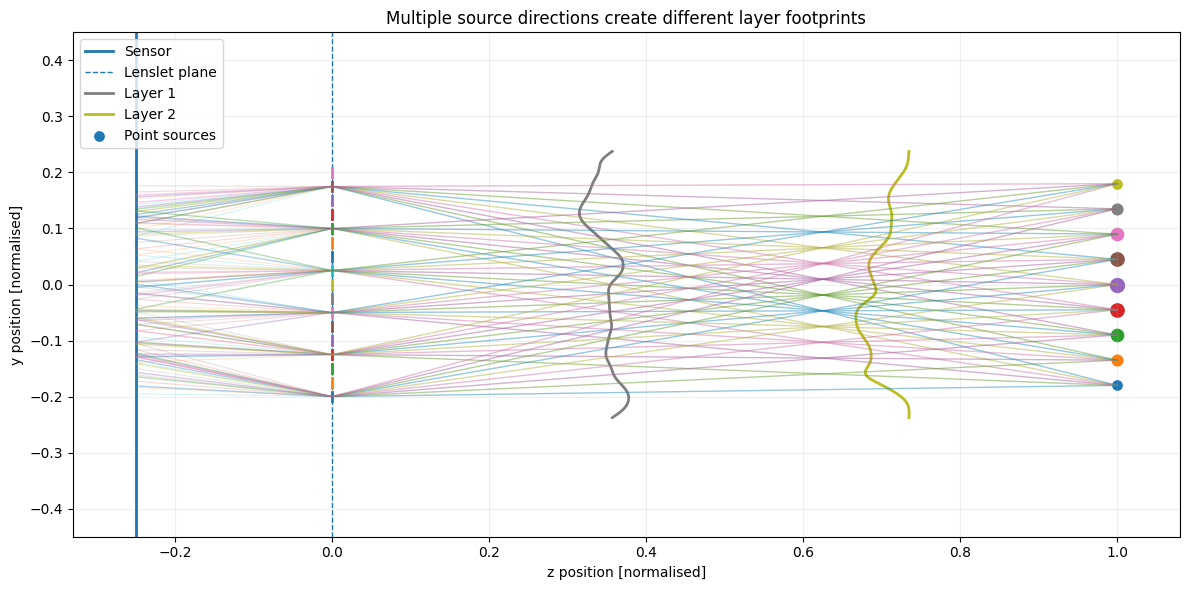

In [5]:
def plot_ray_geometry(rays_reference, rays_aberrated, draw_every_lenslet=3):
    """Visualise source-layer-lenslet geometry."""
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.axvline(z_sensor, linewidth=2, label="Sensor")
    ax.axvline(z_lenslet, linewidth=1, linestyle="--", label="Lenslet plane")

    for y_lens in lenslet_centers_y:
        ax.plot(
            [z_lenslet, z_lenslet],
            [y_lens - lenslet_radius, y_lens + lenslet_radius],
            linewidth=2,
        )

    # Hidden layers are drawn as scaled OPD curves for geometry only.
    for layer in turbulent_layers:
        W_scaled = layer_opd(layer, y_plot)
        W_scaled = W_scaled / np.max(np.abs(W_scaled)) * 0.035
        ax.plot(layer["z"] + W_scaled, y_plot, linewidth=2, label=layer["name"])

    for source_id, (y_source, flux) in enumerate(point_sources):
        ax.scatter(
            z_source, y_source,
            s=100 * flux,
            label="Point sources" if source_id == 0 else None,
        )

    for r_ref, r_ab in zip(rays_reference, rays_aberrated):
        if r_ref["lenslet_id"] % draw_every_lenslet != 0:
            continue

        ax.plot(
            [z_source, z_lenslet, z_sensor],
            [r_ref["y_source"], r_ref["y_lens"], r_ref["y_spot"]],
            alpha=0.18,
            linewidth=0.8,
        )
        ax.plot(
            [z_source, z_lenslet, z_sensor],
            [r_ab["y_source"], r_ab["y_lens"], r_ab["y_spot"]],
            alpha=0.35,
            linewidth=1.0,
        )

    ax.set_xlabel("z position [normalised]")
    ax.set_ylabel("y position [normalised]")
    ax.set_title("Multiple source directions create different layer footprints")
    ax.set_xlim(z_sensor - 0.08, z_source + 0.08)
    ax.set_ylim(-0.45, 0.45)
    ax.grid(alpha=0.2)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


plot_ray_geometry(rays_no_turbulence, rays_with_turbulence)


## 4. Wavefront-Tilt Measurement

The sensor does not measure the two hidden layers separately. For one source-lenslet ray,

$$\theta_{\mathrm{measured}}(s,l)\approx T_1(y_{1,s,l})+T_2(y_{2,s,l}).$$

The measurement stage is shown in two steps:

1. **Ideal coordinate-based baseline** — use the simulated spot coordinate to verify the ray geometry.
2. **Image-based cross-correlation** — estimate the displacement from synthetic lenslet images.

This separates the optical geometry from the image-processing step.


### 4.1 Ideal Coordinate-Based Baseline

Before introducing image processing, we verify the geometry using the exact simulated sensor spot positions.

This is only a baseline check:

$$y_{\mathrm{spot}}\rightarrow\theta_{\mathrm{measured}}.$$

The tomography itself will use the image-based measurements from the next section.


In [6]:
rng_measurement = np.random.default_rng(1)

reference_spots = {
    (r["source_id"], r["lenslet_id"]): r["y_spot"]
    for r in rays_no_turbulence
}

coordinate_baseline_measurements = []

for r in rays_with_turbulence:
    key = (r["source_id"], r["lenslet_id"])

    y_lens = r["y_lens"]
    y_ref = reference_spots[key]
    y_meas = r["y_spot"] + rng_measurement.normal(0.0, measurement_noise_std)

    theta_ref = np.arctan((y_lens - y_ref) / f_ml)
    theta_meas = np.arctan((y_lens - y_meas) / f_ml)

    coordinate_baseline_measurements.append(
        theta_meas - theta_ref
    )

coordinate_baseline_measurements = np.asarray(coordinate_baseline_measurements)
true_summed_tilts = np.asarray([r["theta_turbulence"] for r in rays_with_turbulence])

baseline_rmse = np.sqrt(
    np.mean((coordinate_baseline_measurements - true_summed_tilts)**2)
)

print("Coordinate-based baseline")
print("-------------------------")
print(f"Measurements: {len(coordinate_baseline_measurements)}")
print(f"Baseline tilt RMSE: {baseline_rmse:.3e}")


Coordinate-based baseline
-------------------------
Measurements: 153
Baseline tilt RMSE: 3.037e-17


### 4.2 Image-Based Measurement Using Cross-Correlation

The simulated spot coordinate is now hidden from the estimator. A simple Gaussian spot is rendered for each source-lenslet pair, and the vertical displacement is recovered by cross-correlation.

For one-dimensional profiles,

$$C(\Delta y)=\sum_y I_{\mathrm{meas}}(y)\,I_{\mathrm{ref}}(y+\Delta y).$$

The estimated displacement is

$$\Delta y_{\mathrm{est}}=\arg\max_{\Delta y} C(\Delta y).$$

The displacement is then converted back into an angular tilt through the microlens geometry.

> **Deliberate simplification:** this notebook assumes an aberration-free reference spot for each source-lenslet pair, so it is not reference-free.

> **Image-model simplification:** Gaussian spots are used only to explain the measurement pipeline. Later models replace them with diffraction-based microlens PSFs.


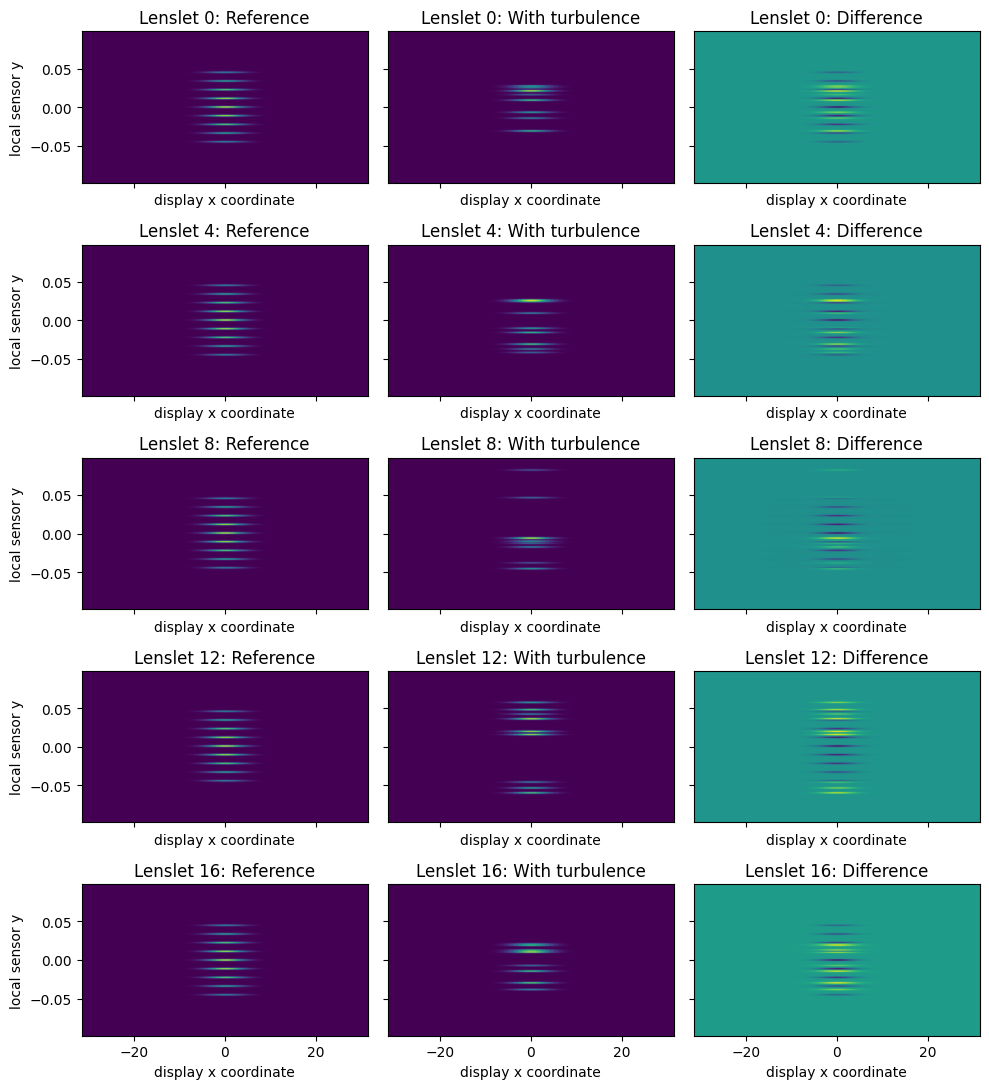

Cross-correlation tilt estimation
Number of image-based measurements: 153
Single-source image y range: ±0.1029
Spot-shift error RMSE: 1.667e-06
Tilt error RMSE:       6.461e-06 rad
Measured summed-tilt std: 9.206e-02 rad


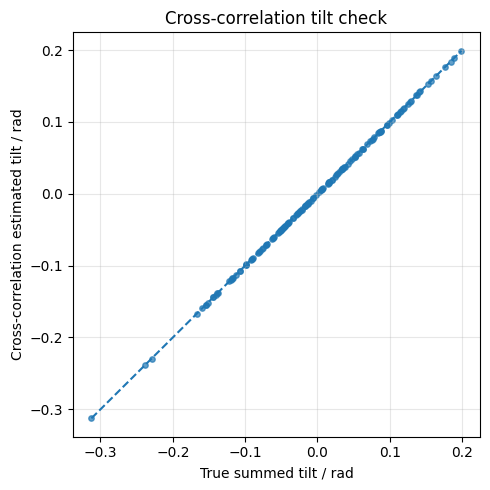

In [7]:
# Build synthetic lenslet images and estimate source-dependent spot shifts by cross correlation.
# This replaces the direct spot-position tilt estimate above with an image-based estimate.

# Keep the number of displayed lenslets small so the figure stays readable.
plot_lenslet_ids = np.linspace(0, n_lenslets - 1, 5, dtype=int)

# Image parameters. The reconstruction is 1D; a narrow display x direction is added
# only to visualise each 1D spot profile as a small sensor image.
combined_ny = 512
combined_nx = 64
single_ny = 512
single_nx = 48
spot_sigma_pix_y = 2.0
spot_sigma_pix_x = 3.0
image_noise_std = 0.0       # try 0.005 or 0.01 later
rng_image = np.random.default_rng(3)

reference_spots = {
    (r["source_id"], r["lenslet_id"]): r["y_spot"]
    for r in rays_no_turbulence
}

measured_spots = {
    (r["source_id"], r["lenslet_id"]): r["y_spot"]
    for r in rays_with_turbulence
}

flux_map = {
    source_id: point_sources[source_id, 1]
    for source_id in range(n_sources)
}

# Each lenslet image is centred on the mean reference position of its 9 spots.
reference_pattern_centres = {}
for lenslet_id in range(n_lenslets):
    ys = [reference_spots[(source_id, lenslet_id)] for source_id in range(n_sources)]
    reference_pattern_centres[lenslet_id] = np.mean(ys)

# Physical y extent for the combined 9-source visualisation.
all_combined_local_y = []
for lenslet_id in range(n_lenslets):
    centre = reference_pattern_centres[lenslet_id]
    for source_id in range(n_sources):
        all_combined_local_y.append(reference_spots[(source_id, lenslet_id)] - centre)
        all_combined_local_y.append(measured_spots[(source_id, lenslet_id)] - centre)

combined_half_width = 1.15 * np.max(np.abs(all_combined_local_y))
combined_y_grid = np.linspace(-combined_half_width, combined_half_width, combined_ny)
combined_dy = combined_y_grid[1] - combined_y_grid[0]
combined_sigma_y = spot_sigma_pix_y * combined_dy
combined_x_grid = np.arange(combined_nx) - (combined_nx - 1) / 2
combined_sigma_x = spot_sigma_pix_x

# Physical y extent for single-source cross correlation.
all_spot_shifts = []
for key in reference_spots:
    all_spot_shifts.append(measured_spots[key] - reference_spots[key])

single_half_width = 1.20 * np.max(np.abs(all_spot_shifts)) + 8 * combined_sigma_y
single_half_width = max(single_half_width, 0.010)
single_y_grid = np.linspace(-single_half_width, single_half_width, single_ny)
single_dy = single_y_grid[1] - single_y_grid[0]
single_sigma_y = spot_sigma_pix_y * single_dy
single_x_grid = np.arange(single_nx) - (single_nx - 1) / 2
single_sigma_x = spot_sigma_pix_x


def gaussian_spot_image(y_grid, x_grid, y0, flux, sigma_y, sigma_x):
    """Make one small 2D Gaussian spot image."""
    gy = np.exp(-0.5 * ((y_grid - y0) / sigma_y)**2)
    gx = np.exp(-0.5 * (x_grid / sigma_x)**2)
    return flux * np.outer(gy, gx)


def make_combined_lenslet_image(lenslet_id, spot_dictionary):
    """Draw the 9-source pattern seen by one lenslet."""
    centre = reference_pattern_centres[lenslet_id]
    image = np.zeros((combined_ny, combined_nx))

    for source_id in range(n_sources):
        y0 = spot_dictionary[(source_id, lenslet_id)] - centre
        flux = flux_map[source_id]
        image += gaussian_spot_image(
            combined_y_grid,
            combined_x_grid,
            y0,
            flux,
            combined_sigma_y,
            combined_sigma_x,
        )

    if image_noise_std > 0:
        image += rng_image.normal(0.0, image_noise_std, size=image.shape)
        image = np.clip(image, 0.0, None)

    if image.max() > 0:
        image = image / image.max()

    return image


def make_single_source_image(y_spot, y_reference, flux):
    """Draw one source spot in a source-centred coordinate system."""
    y0 = y_spot - y_reference
    image = gaussian_spot_image(
        single_y_grid,
        single_x_grid,
        y0,
        flux,
        single_sigma_y,
        single_sigma_x,
    )

    if image_noise_std > 0:
        image += rng_image.normal(0.0, image_noise_std, size=image.shape)
        image = np.clip(image, 0.0, None)

    if image.max() > 0:
        image = image / image.max()

    return image


def estimate_vertical_shift_by_cross_correlation(reference_image, measured_image, dy):
    """Estimate vertical image shift using 1D cross correlation of x-collapsed profiles."""
    reference_profile = reference_image.sum(axis=1)
    measured_profile = measured_image.sum(axis=1)

    reference_profile = reference_profile - np.mean(reference_profile)
    measured_profile = measured_profile - np.mean(measured_profile)

    correlation = np.correlate(measured_profile, reference_profile, mode="full")
    peak_id = np.argmax(correlation)
    lag_pix = peak_id - (len(reference_profile) - 1)

    # Parabolic sub-pixel peak refinement.
    if 0 < peak_id < len(correlation) - 1:
        left = correlation[peak_id - 1]
        centre = correlation[peak_id]
        right = correlation[peak_id + 1]
        denominator = left - 2 * centre + right
        if np.abs(denominator) > 1e-12:
            lag_pix = lag_pix + 0.5 * (left - right) / denominator

    return lag_pix * dy


# Visualise the 9 point-source pattern for a few lenslets.
fig, axes = plt.subplots(
    len(plot_lenslet_ids),
    3,
    figsize=(10, 2.2 * len(plot_lenslet_ids)),
    sharex=True,
    sharey=True,
)

if len(plot_lenslet_ids) == 1:
    axes = axes[None, :]

for row_id, lenslet_id in enumerate(plot_lenslet_ids):
    reference_image = make_combined_lenslet_image(lenslet_id, reference_spots)
    measured_image = make_combined_lenslet_image(lenslet_id, measured_spots)
    difference_image = measured_image - reference_image

    panels = [reference_image, measured_image, difference_image]
    titles = ["Reference", "With turbulence", "Difference"]

    for col_id, (panel, title) in enumerate(zip(panels, titles)):
        ax = axes[row_id, col_id]
        im = ax.imshow(
            panel,
            origin="lower",
            aspect="auto",
            extent=[
                combined_x_grid[0],
                combined_x_grid[-1],
                combined_y_grid[0],
                combined_y_grid[-1],
            ],
        )
        ax.set_title(f"Lenslet {lenslet_id}: {title}")
        if col_id == 0:
            ax.set_ylabel("local sensor y")
        ax.set_xlabel("display x coordinate")

plt.tight_layout()
plt.show()


# Estimate tilt from source-separated cross correlation.
cross_correlation_tilt_measurements = []
shift_errors = []
tilt_errors = []

for r in rays_with_turbulence:
    source_id = r["source_id"]
    lenslet_id = r["lenslet_id"]
    key = (source_id, lenslet_id)

    y_lens = r["y_lens"]
    y_ref = reference_spots[key]
    y_true_meas = measured_spots[key]
    flux = r["flux"]

    reference_image = make_single_source_image(
        y_spot=y_ref,
        y_reference=y_ref,
        flux=flux,
    )
    measured_image = make_single_source_image(
        y_spot=y_true_meas,
        y_reference=y_ref,
        flux=flux,
    )

    shift_est = estimate_vertical_shift_by_cross_correlation(
        reference_image,
        measured_image,
        single_dy,
    )

    y_meas_est = y_ref + shift_est

    theta_ref = np.arctan((y_lens - y_ref) / f_ml)
    theta_meas_est = np.arctan((y_lens - y_meas_est) / f_ml)
    theta_turbulence_est = theta_meas_est - theta_ref

    # Validation only: direct simulated shift/tilt is not used by the inverse solver.
    true_shift = y_true_meas - y_ref
    true_tilt = r["theta_turbulence"]

    shift_errors.append(shift_est - true_shift)
    tilt_errors.append(theta_turbulence_est - true_tilt)

    cross_correlation_tilt_measurements.append({
        "source_id": source_id,
        "lenslet_id": lenslet_id,
        "y_source": r["y_source"],
        "y_lens": y_lens,
        "flux": flux,
        "theta_turbulence_est": theta_turbulence_est,
        "shift_est": shift_est,
    })

# Use image-based cross-correlation measurements for the tomography below.
tilt_measurements = cross_correlation_tilt_measurements

theta_meas_all = np.array([
    row["theta_turbulence_est"] for row in tilt_measurements
])

shift_errors = np.array(shift_errors)
tilt_errors = np.array(tilt_errors)

print("Cross-correlation tilt estimation")
print(f"Number of image-based measurements: {len(tilt_measurements)}")
print(f"Single-source image y range: ±{single_half_width:.4f}")
print(f"Spot-shift error RMSE: {np.sqrt(np.mean(shift_errors**2)):.3e}")
print(f"Tilt error RMSE:       {np.sqrt(np.mean(tilt_errors**2)):.3e} rad")
print(f"Measured summed-tilt std: {np.std(theta_meas_all):.3e} rad")

true_tilts = np.array([r["theta_turbulence"] for r in rays_with_turbulence])
est_tilts = np.array([row["theta_turbulence_est"] for row in tilt_measurements])

plt.figure(figsize=(5, 5))
plt.scatter(true_tilts, est_tilts, s=15, alpha=0.7)
line_min = min(true_tilts.min(), est_tilts.min())
line_max = max(true_tilts.max(), est_tilts.max())
plt.plot([line_min, line_max], [line_min, line_max], "--")
plt.xlabel("True summed tilt / rad")
plt.ylabel("Cross-correlation estimated tilt / rad")
plt.title("Cross-correlation tilt check")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Two-Layer Tomographic Reconstruction

Each image-based measurement is the sum of two unknown layer tilts:

$$b_i=T_1(y_{1,i})+T_2(y_{2,i}).$$

Because a ray usually intersects a layer between reconstruction-grid samples, linear interpolation is used:

$$T(y_i)\approx w_0T(y_j)+w_1T(y_{j+1}).$$

Collecting all source-lenslet measurements gives the linear inverse problem

$$\mathbf{b}=\mathbf{A}\mathbf{x},$$

where the unknown vector contains the tilt samples from both layers:

$$\mathbf{x}=\begin{bmatrix}\mathbf{T}_1\\\mathbf{T}_2\end{bmatrix}.$$

### Why regularisation is needed

Finite measurements cannot independently determine arbitrarily rapid changes at every reconstruction point. A second-difference smoothness condition is therefore added:

$$T_{j-1}-2T_j+T_{j+1}\approx 0.$$

There is also a weak **layer-wise gauge ambiguity**: a nearly constant tilt can be transferred from one layer to the other without strongly changing their sum. A zero-mean constraint helps fix this ambiguity.

The final augmented least-squares system is

$$\begin{bmatrix}\mathbf{A}\\\lambda_{\mathrm{smooth}}\mathbf{L}\\\lambda_{\mathrm{mean}}\mathbf{M}\end{bmatrix}\mathbf{x}=\begin{bmatrix}\mathbf{b}\\\mathbf{0}\\\mathbf{0}\end{bmatrix}.$$


In [8]:
def interpolation_weights(grid, x):
    """Linear interpolation weights for position x on a 1D grid."""
    if x <= grid[0]:
        return [(0, 1.0)]
    if x >= grid[-1]:
        return [(len(grid) - 1, 1.0)]

    j = np.searchsorted(grid, x) - 1
    x0, x1 = grid[j], grid[j + 1]
    w1 = (x - x0) / (x1 - x0)
    w0 = 1.0 - w1
    return [(j, w0), (j + 1, w1)]


# Reconstruction grid for each hidden layer.
n_layer_grid = n_lenslets
layer_grids = []

for layer in turbulent_layers:
    layer_hits = [
        y_at_layer(row["y_source"], row["y_lens"], layer["z"])
        for row in tilt_measurements
    ]
    extent = np.max(np.abs(layer_hits)) + 0.5 * lenslet_pitch
    layer_grids.append(np.linspace(-extent, extent, n_layer_grid))


# Build the measurement matrix A.
n_unknowns = len(turbulent_layers) * n_layer_grid
A_rows = []
b_values = []

for row in tilt_measurements:
    A_row = np.zeros(n_unknowns)

    for layer_id, layer in enumerate(turbulent_layers):
        y_hit = y_at_layer(
            row["y_source"],
            row["y_lens"],
            layer["z"],
        )
        offset = layer_id * n_layer_grid

        for grid_id, weight in interpolation_weights(layer_grids[layer_id], y_hit):
            A_row[offset + grid_id] += weight

    A_rows.append(A_row)
    b_values.append(row["theta_turbulence_est"])

A = np.vstack(A_rows)
b = np.asarray(b_values)


# Regularisation.
lambda_smooth = 0.02
lambda_mean = 1.0

regularisation_rows = []
regularisation_values = []

for layer_id in range(len(turbulent_layers)):
    offset = layer_id * n_layer_grid

    # Second-difference smoothness.
    for j in range(1, n_layer_grid - 1):
        row = np.zeros(n_unknowns)
        row[offset + j - 1] = 1.0
        row[offset + j] = -2.0
        row[offset + j + 1] = 1.0
        regularisation_rows.append(lambda_smooth * row)
        regularisation_values.append(0.0)

    # Layer-wise zero-mean tilt gauge.
    row = np.zeros(n_unknowns)
    row[offset:offset + n_layer_grid] = 1.0 / n_layer_grid
    regularisation_rows.append(lambda_mean * row)
    regularisation_values.append(0.0)

A_augmented = np.vstack([A, np.vstack(regularisation_rows)])
b_augmented = np.concatenate([b, np.asarray(regularisation_values)])

solution, residuals, rank, singular_values = np.linalg.lstsq(
    A_augmented,
    b_augmented,
    rcond=None,
)

model_tilt = A @ solution
measurement_fit_rmse = np.sqrt(np.mean((model_tilt - b)**2))

print("Tomography summary")
print("------------------")
print(f"Measurements:             {A.shape[0]}")
print(f"Unknowns:                 {A.shape[1]}")
print(f"Augmented system rank:    {rank}")
print(f"Forward-fit RMSE:         {measurement_fit_rmse:.3e}")
print()

for layer_id, layer in enumerate(turbulent_layers):
    offset = layer_id * n_layer_grid
    y_grid = layer_grids[layer_id]

    tilt_est = solution[offset:offset + n_layer_grid]
    tilt_true = layer_tilt(layer, y_grid)

    tilt_est_zero_mean = tilt_est - np.mean(tilt_est)
    tilt_true_zero_mean = tilt_true - np.mean(tilt_true)

    tilt_rmse = np.sqrt(
        np.mean((tilt_est_zero_mean - tilt_true_zero_mean)**2)
    )
    tilt_corr = np.corrcoef(
        tilt_est_zero_mean,
        tilt_true_zero_mean,
    )[0, 1]

    layer["estimation_y_grid"] = y_grid
    layer["estimated_tilt"] = tilt_est
    layer["true_tilt_on_estimation_grid"] = tilt_true
    layer["tilt_rmse"] = tilt_rmse
    layer["tilt_corr"] = tilt_corr

    print(layer["name"])
    print(f"  tilt RMSE:        {tilt_rmse:.3e}")
    print(f"  correlation:      {tilt_corr:.3f}")


Tomography summary
------------------
Measurements:             153
Unknowns:                 34
Augmented system rank:    34
Forward-fit RMSE:         1.493e-02

Layer 1
  tilt RMSE:        3.855e-02
  correlation:      0.882
Layer 2
  tilt RMSE:        5.459e-02
  correlation:      0.919


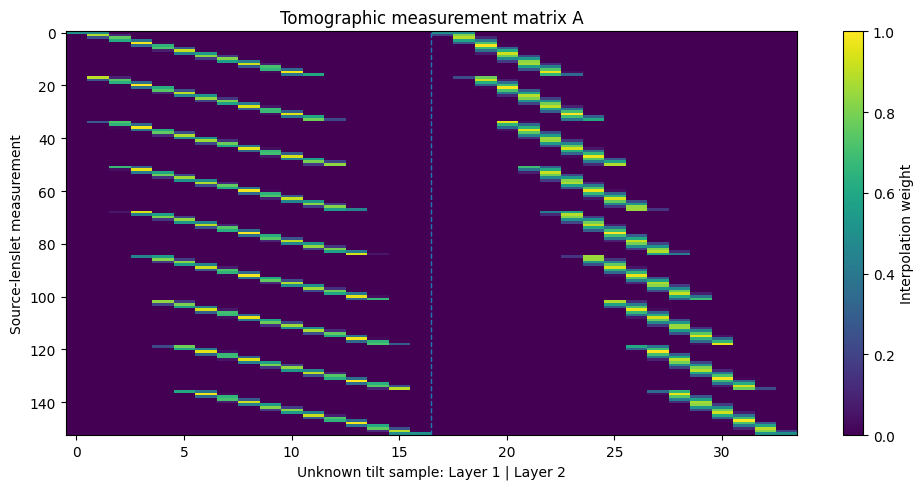

In [9]:
# Visualise how each measurement couples to both hidden layers.
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(A, aspect="auto", interpolation="nearest")

ax.axvline(n_layer_grid - 0.5, linestyle="--", linewidth=1)
ax.set_xlabel("Unknown tilt sample: Layer 1 | Layer 2")
ax.set_ylabel("Source-lenslet measurement")
ax.set_title("Tomographic measurement matrix A")
plt.colorbar(im, ax=ax, label="Interpolation weight")
plt.tight_layout()
plt.show()


## 6. OPD Reconstruction and Validation

The estimated layer slope is integrated to recover the OPD shape:

$$W(y)=\int \frac{dW}{dy}\,dy.$$

A slope sensor cannot determine absolute **piston**. In this simplified two-layer problem, the layer-wise global tilt is also weakly identifiable.

Therefore, piston and the best-fit linear term are removed when comparing reconstructed and hidden OPD shapes. The hidden OPD is used only for validation, not by the reconstructor.


In [10]:
def reconstruct_wavefront_from_tilt(y_grid, local_tilt):
    """Integrate local slope with the trapezoidal rule."""
    order = np.argsort(y_grid)
    y_sorted = y_grid[order]
    tilt_sorted = local_tilt[order]

    W_est = np.zeros_like(y_sorted)
    dy = np.diff(y_sorted)
    W_est[1:] = np.cumsum(
        0.5 * (tilt_sorted[:-1] + tilt_sorted[1:]) * dy
    )
    W_est -= np.mean(W_est)
    return y_sorted, W_est, tilt_sorted


def remove_piston_and_linear_tilt(y, W):
    """Remove piston and best-fit linear term for shape comparison."""
    coeff = np.polyfit(y, W, deg=1)
    return W - np.polyval(coeff, y)


for layer in turbulent_layers:
    y_grid = layer["estimation_y_grid"]

    tilt_est = layer["estimated_tilt"] - np.mean(layer["estimated_tilt"])
    y_rec, W_est, tilt_used = reconstruct_wavefront_from_tilt(y_grid, tilt_est)

    W_true = layer_opd(layer, y_rec)

    W_est_compare = remove_piston_and_linear_tilt(y_rec, W_est)
    W_true_compare = remove_piston_and_linear_tilt(y_rec, W_true)

    wavefront_rmse = np.sqrt(
        np.mean((W_est_compare - W_true_compare)**2)
    )

    layer["y_rec"] = y_rec
    layer["W_est"] = W_est_compare
    layer["W_true_compare"] = W_true_compare
    layer["wavefront_rmse"] = wavefront_rmse

    print(
        f"{layer['name']}: OPD-shape RMSE after piston/linear removal = "
        f"{wavefront_rmse:.3e}"
    )


Layer 1: OPD-shape RMSE after piston/linear removal = 5.062e-04
Layer 2: OPD-shape RMSE after piston/linear removal = 5.163e-04


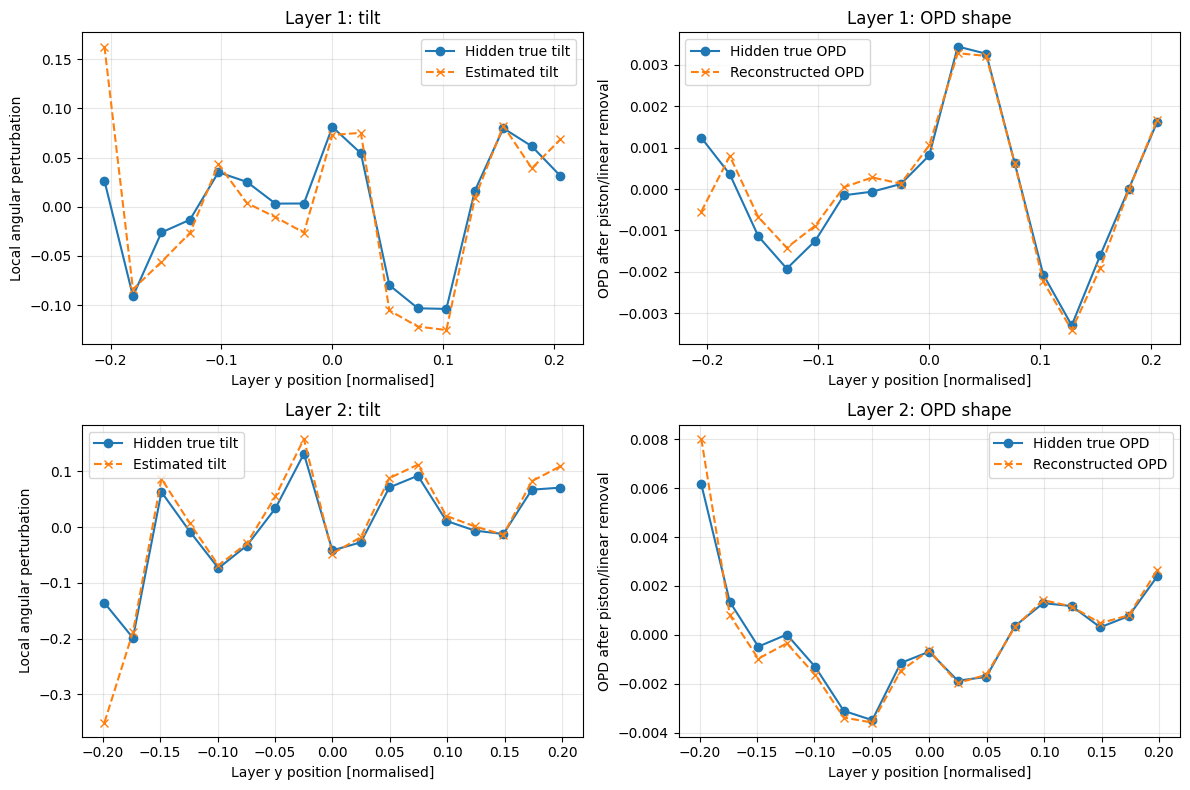

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for layer_id, layer in enumerate(turbulent_layers):
    y_grid = layer["estimation_y_grid"]

    tilt_est = layer["estimated_tilt"] - np.mean(layer["estimated_tilt"])
    tilt_true = (
        layer["true_tilt_on_estimation_grid"]
        - np.mean(layer["true_tilt_on_estimation_grid"])
    )

    axes[layer_id, 0].plot(y_grid, tilt_true, marker="o", label="Hidden true tilt")
    axes[layer_id, 0].plot(
        y_grid, tilt_est,
        marker="x", linestyle="--",
        label="Estimated tilt",
    )
    axes[layer_id, 0].set_title(f"{layer['name']}: tilt")
    axes[layer_id, 0].set_xlabel("Layer y position [normalised]")
    axes[layer_id, 0].set_ylabel("Local angular perturbation")
    axes[layer_id, 0].grid(alpha=0.3)
    axes[layer_id, 0].legend()

    axes[layer_id, 1].plot(
        layer["y_rec"],
        layer["W_true_compare"],
        marker="o",
        label="Hidden true OPD",
    )
    axes[layer_id, 1].plot(
        layer["y_rec"],
        layer["W_est"],
        marker="x",
        linestyle="--",
        label="Reconstructed OPD",
    )
    axes[layer_id, 1].set_title(f"{layer['name']}: OPD shape")
    axes[layer_id, 1].set_xlabel("Layer y position [normalised]")
    axes[layer_id, 1].set_ylabel("OPD after piston/linear removal")
    axes[layer_id, 1].grid(alpha=0.3)
    axes[layer_id, 1].legend()

plt.tight_layout()
plt.show()


## 7. Forward Consistency Check

A reconstruction should not only resemble the hidden truth. When propagated through the measurement model, it should also reproduce the observed summed tilts.

The check is

$$\mathbf{A}\hat{\mathbf{x}}\approx\mathbf{b}.$$

A low forward residual is necessary, although it does not by itself prove that every hidden layer has been uniquely recovered.


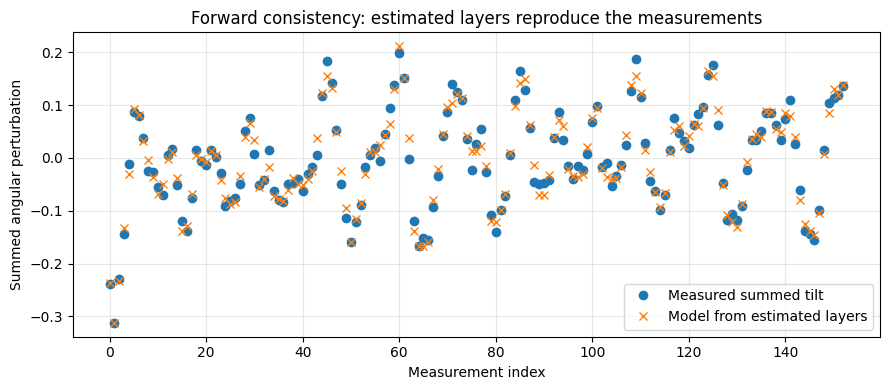

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(b, marker="o", linestyle="", label="Measured summed tilt")
ax.plot(model_tilt, marker="x", linestyle="", label="Model from estimated layers")

ax.set_xlabel("Measurement index")
ax.set_ylabel("Summed angular perturbation")
ax.set_title("Forward consistency: estimated layers reproduce the measurements")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


## 8. Limitations, Next Steps, and Key Takeaways

### What this model does not claim

This notebook intentionally does not model:

1. Full 2D wavefront fields $W(x,y)$.
2. Physical diffraction from the microlens aperture.
3. Reference-free image registration.
4. Realistic photon noise, read noise, and detector response.
5. Full atmospheric propagation or closed-loop AO.

The Gaussian spot model and clean reference are deliberate simplifications so that the geometry and inverse problem remain transparent.

### Key takeaways

- A WFS measurement does not directly reveal the individual hidden layers.
- Multiple source directions create different layer footprints and provide **tomographic diversity**.
- Lenslet image displacement can be converted into local wavefront slope.
- The layer-separation problem can be written as $\mathbf{b}=\mathbf{A}\mathbf{x}$.
- Regularisation is needed because some layer modes are weakly constrained.
- Estimated slopes can be integrated to recover each layer's OPD shape.
- A useful reconstruction should pass both **ground-truth validation** and a **forward-consistency check**.

### References

- T. R. Rimmele and J. Marino, *Solar Adaptive Optics*, Living Reviews in Solar Physics, 2011.
- R. J. Noll, *Zernike Polynomials and Atmospheric Turbulence*, Journal of the Optical Society of America, 1976.
- A. Glindemann, R. G. Lane, and J. C. Dainty, *Simulation of Time-evolving Speckle Patterns Using Kolmogorov Statistics*, Journal of Modern Optics, 1993.

This notebook is intended as the simplest conceptual entry point in the repository. Later notebooks can replace the deliberate simplifications one by one: **1D → 2D**, **Gaussian → diffraction PSF**, **clean reference → self-reference**, and **toy layers → physical AO imaging**.
